In [27]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import preprocessing as pp
import segmentation as seg
import feature_extraction as fe
import hazard_mapping as hm

# =====================================================================
# TEAM RUN CONFIGURATION (Modify this section for new OHRC images)
# =====================================================================
CONFIG = {
    "image_path": "BAH6.png",  # Path to your target lunar image
    "denoising_ksize": 5,                         # Filter strength
    "clahe_clip_limit": 2.5,                      # Contrast enhancement setting
    "hough_settings": {
        "dp": 1.5,                                # Accumulator downsampling
        "min_dist": 200,                          # Min distance between detected craters
        "param1": 50,                             # Upper Canny threshold
        "param2": 65,                             # Hough voting threshold
        "min_radius": 25,                         # Minimum crater size (pixels)
        "max_radius": 200                         # Maximum crater size (pixels)
    },
    "hazard_weights": {
        "w_psr": 0.5,                             # Deep Shadow/PSR penalty weight
        "w_slope": 0.3,                           # Topographical Slope penalty weight
        "w_rough": 0.2                            # Surface Roughness penalty weight
    },
    "output_prefix": "lunar_site_alpha"           # Filename prefix for team exports
}

In [28]:
def run_templated_lunar_pipeline(config: dict):
    """
    Executes the entire modular vision stack sequentially using the provided parameters.
    """
    print(f" Ready: Ingesting image layer -> {config['image_path']}")
    img = cv2.imread(config['image_path'], cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Execution halted: Could not locate image at {config['image_path']}")
        
    # Step 1: Preprocessing & Contrast Calibration
    calibrated = pp.calibrate_and_normalize(img)
    denoised = pp.apply_denoising(calibrated, ksize=config['denoising_ksize'])
    clahe_img = pp.enhance_contrast(denoised, clip_limit=config['clahe_clip_limit'])
    
    # Step 2: 3-Class Categorical Multi-Otsu Structural Masking
    regions, psr_fraction = seg.compute_multiotsu_mask(clahe_img)
    
    # Step 3: Feature Extraction (Continuous Gradients & Texture Roughness)
    sobel_map = fe.compute_sobel_gradient(clahe_img, ksize=3)
    gabor_map = fe.compute_gabor_roughness(clahe_img, num_angles=8)
    
    # Step 4: Shadow-Cross Referenced Crater Analytics
    # Uses a wrapper to pass dynamic parameters seamlessly 
    blurred = cv2.GaussianBlur(clahe_img, (9, 9), 2)
    h_set = config['hough_settings']
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=h_set['dp'], minDist=h_set['min_dist'],
        param1=h_set['param1'], param2=h_set['param2'], 
        minRadius=h_set['min_radius'], maxRadius=h_set['max_radius']
    )
    
    crater_metadata = []
    visual_circles = []
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i, circle in enumerate(circles[0, :]):
            cx, cy, r = int(circle[0]), int(circle[1]), int(circle[2])
            h, w = clahe_img.shape
            if 0 <= cx < w and 0 <= cy < h:
                center_region = regions[max(0, cy - 5):min(h, cy + 5), max(0, cx - 5):min(w, cx + 5)]
                is_shadowed = np.mean(center_region == 0) > 0.5
                crater_metadata.append({
                    "Crater_ID": i, "Center_X": cx, "Center_Y": cy, "Radius_px": r, "High_Ice_Probability": bool(is_shadowed)
                })
                visual_circles.append([cx, cy, r, is_shadowed])
                
    # Step 5: Linear Combined Landing Site Hazard Mapping
    w = config['hazard_weights']
    composite_hazard, safe_fraction = hm.generate_suitability_map(
        regions, sobel_map, gabor_map, w['w_psr'], w['w_slope'], w['w_rough']
    )
    
    # Package processing pipeline elements together
    return {
        "processed_img": clahe_img, "regions_mask": regions, "sobel_map": sobel_map,
        "gabor_map": gabor_map, "hazard_map": composite_hazard, "craters_df": pd.DataFrame(crater_metadata),
        "visual_circles": visual_circles, "metrics": {"psr_fraction": psr_fraction, "safe_fraction": safe_fraction}
    }

In [29]:
# Execute the full stack
outputs = run_templated_lunar_pipeline(CONFIG)

# Display Quantitative Status Metrics for Mission Teams
print(f"\n==========================================================")
print(f"   ANALYTICAL REPORT FOR TEAM: {CONFIG['output_prefix'].upper()}")
print(f"==========================================================")
print(f"-> Total Regional PSR Ice Candidate Coverage: {outputs['metrics']['psr_fraction'] * 100:.2f}%")
print(f"-> Ideal Safe Operational Landing Zones Identified: {outputs['metrics']['safe_fraction'] * 100:.2f}%")
print(f"-> Active Structural Craters Logged into Registry: {len(outputs['craters_df'])}")
if len(outputs['craters_df']) > 0:
    print(f"-> Confirmed Volatile-Rich Shadow Traps (High Ice Prob.): {outputs['craters_df']['High_Ice_Probability'].sum()}")
print(f"==========================================================\n")

# Display the top of the generated DataFrame
display(outputs['craters_df'].head())

 Ready: Ingesting image layer -> BAH6.png

   ANALYTICAL REPORT FOR TEAM: LUNAR_SITE_ALPHA
-> Total Regional PSR Ice Candidate Coverage: 35.88%
-> Ideal Safe Operational Landing Zones Identified: 63.54%
-> Active Structural Craters Logged into Registry: 73
-> Confirmed Volatile-Rich Shadow Traps (High Ice Prob.): 26



,Crater_ID,Center_X,Center_Y,Radius_px,High_Ice_Probability
0,0,1067,433,199,True
1,1,1030,187,179,False
2,2,1534,205,199,False
3,3,205,250,199,False
4,4,2138,205,194,True


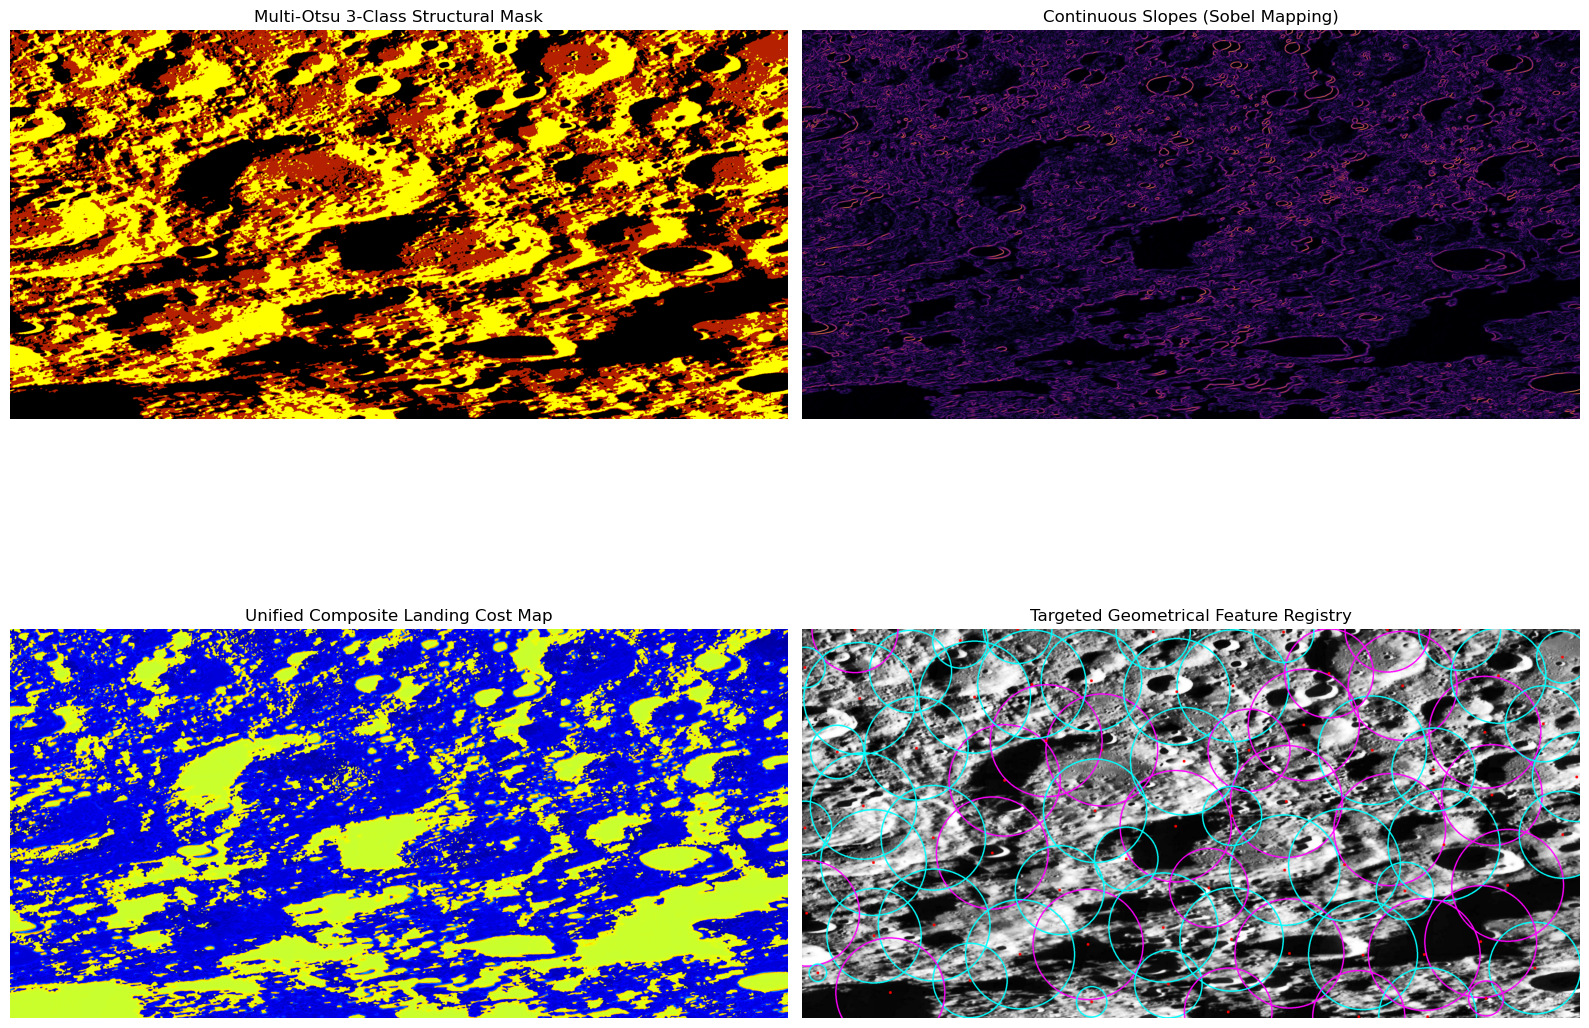

 Deliverables exported successfully:
  - [lunar_site_alpha_crater_registry.csv] exported for Rover Navigation pathfinders.
  - [lunar_site_alpha_composite_hazard_matrix.tif] and Structural Masks exported for GIS layers.


In [32]:
# 1. Generate Annotated Crater Registry Overlay Image
vis_img = cv2.cvtColor(outputs['processed_img'], cv2.COLOR_GRAY2BGR)
for cx, cy, r, is_shadowed in outputs['visual_circles']:
    # Only draw it if it's a high-probability shadow trap
    if is_shadowed:
        cv2.circle(vis_img, (cx, cy), r, (255, 0, 255), 3) # Keep Magenta circles
    color = (255, 0, 255) if is_shadowed else (255, 255, 0) # Magenta = Shadowed, Cyan = Illuminated
    cv2.circle(vis_img, (cx, cy), r, color, 3)
    cv2.circle(vis_img, (cx, cy), 5, (0, 0, 255), -1)

# 2. Render Team Visualization Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes[0, 0].imshow(outputs['regions_mask'], cmap='gnuplot')
axes[0, 0].set_title("Multi-Otsu 3-Class Structural Mask")
axes[0, 0].axis('off')

axes[0, 1].imshow(outputs['sobel_map'], cmap='inferno')
axes[0, 1].set_title("Continuous Slopes (Sobel Mapping)")
axes[0, 1].axis('off')

axes[1, 0].imshow(outputs['hazard_map'], cmap='jet')
axes[1, 0].set_title("Unified Composite Landing Cost Map")
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Targeted Geometrical Feature Registry")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# 3. Save and Export Deliverables for GIS and Rover Navigation Teams
prefix = CONFIG['output_prefix']
outputs['craters_df'].to_csv(f"{prefix}_crater_registry.csv", index=False)
cv2.imwrite(f"{prefix}_composite_hazard_matrix.tif", (outputs['hazard_map'] * 255).astype(np.uint8))
cv2.imwrite(f"{prefix}_otsu_structural_mask.png", outputs['regions_mask'])

print(f" Deliverables exported successfully:")
print(f"  - [{prefix}_crater_registry.csv] exported for Rover Navigation pathfinders.")
print(f"  - [{prefix}_composite_hazard_matrix.tif] and Structural Masks exported for GIS layers.")

In [31]:
# Open and read the first 10 lines of your exported file
with open("lunar_site_alpha_crater_registry.csv", "r") as file:
    for i in range(10):
        print(file.readline().strip())

Crater_ID,Center_X,Center_Y,Radius_px,High_Ice_Probability
0,1067,433,199,True
1,1030,187,179,False
2,1534,205,199,False
3,205,250,199,False
4,2138,205,194,True
5,407,427,184,False
6,721,541,198,True
7,218,632,189,False
8,1330,704,198,True
